In [14]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path('muon_tag_analysis')
PLOT_DIR.mkdir(exist_ok=True)

In [15]:
H5_FILE = '/data/user/tvaneede/muon_tagging/data_processing/output/h5/merged.h5'

with h5py.File(H5_FILE, 'r') as f:
    reco_etot = f['RecoETot']['value'][:]  # GeV

print(f'Total events: {len(reco_etot)}')
print(f'Energy range: {reco_etot.min():.0f} – {reco_etot.max():.0f} GeV')

Total events: 30
Energy range: 14902 – 209547 GeV


In [16]:
PARQUET = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split'
    '/IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1'
    '/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen'
    '/bdt1_0.333333_bdt2_0.366667_length_10'
    '/dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_track.parquet'
)
LIVETIME = 411785301.60  # seconds

df = pd.read_parquet(PARQUET)
df_muon = df[~np.isnan(df['MuonWeight'])].copy()
df_muon['MuonWeight'] /= 2.1  # rescale back — error from Neha

sim_energy  = df_muon['reco_energy'].values   # GeV
sim_weights = df_muon['MuonWeight'].values * LIVETIME

print(f'Simulation events (muon): {len(sim_energy)}')
print(f'Weighted sum: {sim_weights.sum():.2f}')

Simulation events (muon): 41
Weighted sum: 7.84


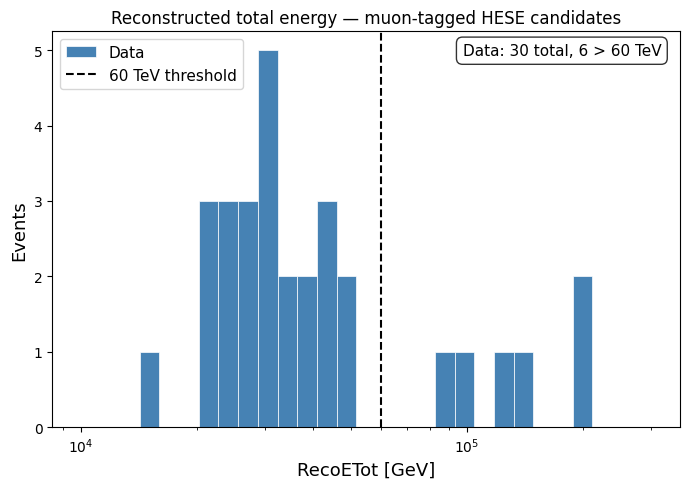

In [20]:
E_THRESHOLD = 60e3  # GeV (60 TeV)

n_total = len(reco_etot)
n_above  = np.sum(reco_etot > E_THRESHOLD)

bins = np.logspace(np.log10(10e3), np.log10(300e3), 30)  # 10–300 TeV in GeV

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(reco_etot, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5,
        label='Data')
ax.axvline(E_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label='60 TeV threshold')

ax.set_xscale('log')
ax.set_xlabel('RecoETot [GeV]', fontsize=13)
ax.set_ylabel('Events', fontsize=13)
ax.set_title('Reconstructed total energy — muon-tagged HESE candidates', fontsize=12)

textstr = f'Data: {n_total} total, {n_above} > 60 TeV'
ax.text(0.97, 0.97, textstr, transform=ax.transAxes,
        fontsize=11, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'reco_etot_data.pdf', bbox_inches='tight')
plt.show()

In [18]:
def data_over_sim(n_data, w):
    """
    Fraction = N_data / sum(w)
    Error propagation:
      sigma_data = sqrt(N_data)            (Poisson)
      sigma_sim  = sqrt(sum(w_i^2))        (weighted sum uncertainty)
      sigma_frac = frac * sqrt((1/N_data) + (sum(w^2)/sum(w)^2))
    """
    W = w.sum()
    frac = n_data / W
    sigma_data = np.sqrt(n_data)
    sigma_sim  = np.sqrt((w**2).sum())
    sigma_frac = frac * np.sqrt((sigma_data / n_data)**2 + (sigma_sim / W)**2)
    return frac, sigma_frac, n_data, sigma_data, W, sigma_sim

mask_above = reco_etot > E_THRESHOLD
w_all   = sim_weights
w_above = sim_weights[sim_energy > E_THRESHOLD]

frac_all,   err_all,   nd_all,   nd_all_err,   ws_all,   ws_all_err   = data_over_sim(n_total,          w_all)
frac_above, err_above, nd_above, nd_above_err, ws_above, ws_above_err = data_over_sim(int(n_above), w_above)

print("All events:")
print(f"  Data:        {nd_all:.0f}  ± {nd_all_err:.1f}")
print(f"  Simulation:  {ws_all:.2f} ± {ws_all_err:.2f}")
print(f"  Fraction:    {frac_all:.2f} ± {err_all:.2f}")
print()
print(f"Events > 60 TeV:")
print(f"  Data:        {nd_above:.0f}  ± {nd_above_err:.1f}")
print(f"  Simulation:  {ws_above:.2f} ± {ws_above_err:.2f}")
print(f"  Fraction:    {frac_above:.2f} ± {err_above:.2f}")

All events:
  Data:        30  ± 5.5
  Simulation:  7.84 ± 2.92
  Fraction:    3.82 ± 1.59

Events > 60 TeV:
  Data:        6  ± 2.4
  Simulation:  0.20 ± 0.07
  Fraction:    30.26 ± 16.76


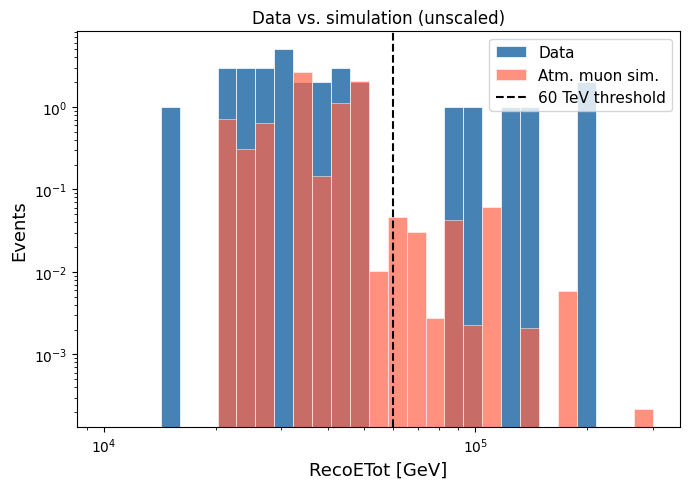

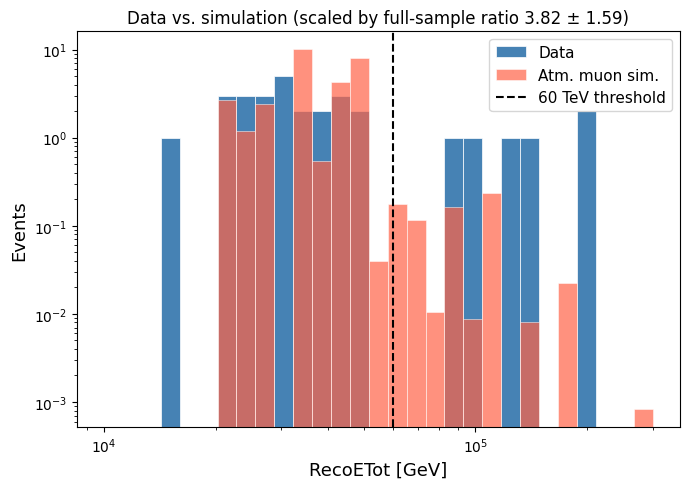

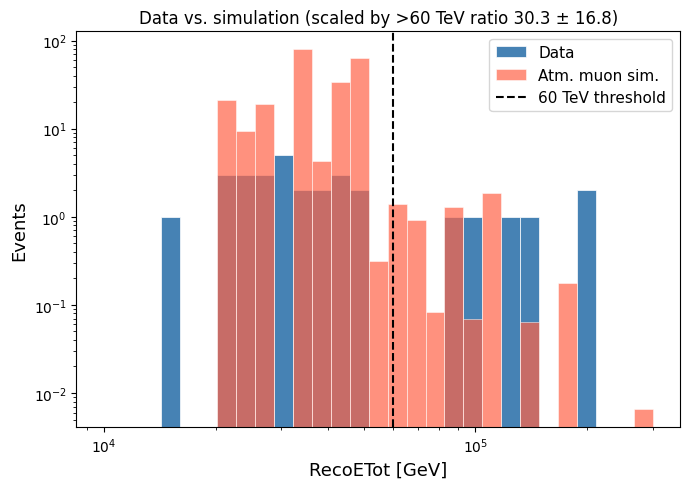

In [21]:
def plot_data_sim(reco_etot, sim_energy, sim_weights, bins, title, fname):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(reco_etot, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5,
            label='Data')
    ax.hist(sim_energy, bins=bins, weights=sim_weights,
            color='tomato', edgecolor='white', linewidth=0.5, alpha=0.7,
            label='Atm. muon sim.')
    ax.axvline(E_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
               label='60 TeV threshold')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('RecoETot [GeV]', fontsize=13)
    ax.set_ylabel('Events', fontsize=13)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / fname, bbox_inches='tight')
    plt.show()


# Unscaled
plot_data_sim(reco_etot, sim_energy, sim_weights, bins,
              title='Data vs. simulation (unscaled)',
              fname='reco_etot_data_sim.pdf')

# Scaled by fraction from full sample
plot_data_sim(reco_etot, sim_energy, sim_weights * frac_all, bins,
              title=f'Data vs. simulation (scaled by full-sample ratio {frac_all:.2f} ± {err_all:.2f})',
              fname='reco_etot_data_sim_scaled_all.pdf')

# Scaled by fraction from > 60 TeV sample
plot_data_sim(reco_etot, sim_energy, sim_weights * frac_above, bins,
              title=f'Data vs. simulation (scaled by >60 TeV ratio {frac_above:.1f} ± {err_above:.1f})',
              fname='reco_etot_data_sim_scaled_above60tev.pdf')